In [21]:
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

np.random.seed(42)

# Loding of mars crater dataset

df = pd.read_csv('_2c7ec69d0edd3b9599c0df80f0901a52_marscrater_pds.csv')

print(f'Original dataset shape: {df.shape}')
print(f'no of craters :{df.shape[0]:,}')

Original dataset shape: (384343, 10)
no of craters :384,343


In [12]:
df['HAS_LAYERS'] = (df['NUMBER_LAYERS'] > 0).astype(int)

print("TARGET VARIABLE: HAS_LAYERS")
print("  0 = No ejecta layers (simple crater)")
print("  1 = Has ejecta layers (complex crater)")
print("\nTarget distribution:")
print(df['HAS_LAYERS'].value_counts())
print(f"\nPercentage with/ layers: {(df['HAS_LAYERS'].sum() / len(df) * 100):.2f}%")

TARGET VARIABLE: HAS_LAYERS
  0 = No ejecta layers (simple crater)
  1 = Has ejecta layers (complex crater)

Target distribution:
0    364612
1     19731
Name: HAS_LAYERS, dtype: int64

Percentage with/ layers: 5.13%


In [13]:
#selection of explanatory variable from latitude position

explanatory_vars = ['LATITUDE_CIRCLE_IMAGE', 'LONGITUDE_CIRCLE_IMAGE', 
                    'DIAM_CIRCLE_IMAGE', 'DEPTH_RIMFLOOR_TOPOG']

print("EXPLANATORY VARIABLES:")
for i, var in enumerate(explanatory_vars, 1):
    print(f"  {i}. {var}")

# Clean the data (remove invalid values)
df_clean = df[explanatory_vars + ['HAS_LAYERS']].copy()
df_clean = df_clean[df_clean['DEPTH_RIMFLOOR_TOPOG'] >= 0]

print(f"\nDataset size after cleaning: {len(df_clean):,} craters")


EXPLANATORY VARIABLES:
  1. LATITUDE_CIRCLE_IMAGE
  2. LONGITUDE_CIRCLE_IMAGE
  3. DIAM_CIRCLE_IMAGE
  4. DEPTH_RIMFLOOR_TOPOG

Dataset size after cleaning: 384,333 craters


In [14]:
#Creating training and test sets
sample_size = 20000
df_sample, _ = train_test_split(df_clean, 
                                 train_size=sample_size, 
                                 stratify=df_clean['HAS_LAYERS'],
                                 random_state=42)

print(f"Working sample size: {len(df_sample):,} craters")

#features of the data
X = df_sample[explanatory_vars]
y = df_sample['HAS_LAYERS']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set: {len(X_train):,} craters")
print(f"Test set: {len(X_test):,} craters")

Working sample size: 20,000 craters

Training set: 14,000 craters
Test set: 6,000 craters


In [17]:
#Build of classification tree for the dataset

#Classifier for decision tree

dt_classifier = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    random_state=42
)

#fiting classifiers

dt_classifier.fit(X_train, y_train)


print("Decision Tree Model Successfully Trained!")
print(f"\nModel Parameters:")
print(f"  - Criterion: {dt_classifier.criterion}")
print(f"  - Max depth: {dt_classifier.max_depth}")
print(f"  - Min samples split: {dt_classifier.min_samples_split}")
print(f"  - Min samples leaf: {dt_classifier.min_samples_leaf}")


Decision Tree Model Successfully Trained!

Model Parameters:
  - Criterion: gini
  - Max depth: 5
  - Min samples split: 50
  - Min samples leaf: 25


In [22]:
#performance matrices and evaluation of model

#predication set
y_pred_train = dt_classifier.predict(X_train)
y_pred_test = dt_classifier.predict(X_test)

#accuracy calculation using matrices function
train_accuracy = metrics.accuracy_score(y_train, y_pred_train)
test_accuracy = metrics.accuracy_score(y_test, y_pred_test)

print("PERFORMANCE:")
print(f"  Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

MODEL PERFORMANCE:
  Training Accuracy: 0.9564 (95.64%)
  Test Accuracy: 0.9548 (95.48%)


In [24]:
# Confusion Matrix
print("Confusion Matrix (Test Set):")
cm = metrics.confusion_matrix(y_test, y_pred_test)
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (Correctly predicted no layers): {cm[0,0]:,}")
print(f"  False Positives (Incorrectly predicted layers): {cm[0,1]:,}")
print(f"  False Negatives (Incorrectly predicted no layers): {cm[1,0]:,}")
print(f"  True Positives (Correctly predicted layers): {cm[1,1]:,}")

# Classification 
print("\nDetailed Classification Report:")
print(metrics.classification_report(y_test, y_pred_test, 
                                    target_names=['No Layers', 'Has Layers']))

# Additional metrics
precision = metrics.precision_score(y_test, y_pred_test)
recall = metrics.recall_score(y_test, y_pred_test)
f1 = metrics.f1_score(y_test, y_pred_test)

print("Additional Performance Metrics:")
print(f"  Precision: {precision:.4f}")
print(f"  Recall (Sensitivity): {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")

Confusion Matrix (Test Set):
[[5599   93]
 [ 178  130]]

Interpretation:
  True Negatives (Correctly predicted no layers): 5,599
  False Positives (Incorrectly predicted layers): 93
  False Negatives (Incorrectly predicted no layers): 178
  True Positives (Correctly predicted layers): 130

Detailed Classification Report:
              precision    recall  f1-score   support

   No Layers       0.97      0.98      0.98      5692
  Has Layers       0.58      0.42      0.49       308

    accuracy                           0.95      6000
   macro avg       0.78      0.70      0.73      6000
weighted avg       0.95      0.95      0.95      6000

Additional Performance Metrics:
  Precision: 0.5830
  Recall (Sensitivity): 0.4221
  F1-Score: 0.4896


In [26]:
#features analysis 
feature_importance = pd.DataFrame({
    'Feature': explanatory_vars,
    'Importance': dt_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Rankings:")
print("(Shows which variables are most important in predicting ejecta layers)")
print()
for idx, row in feature_importance.iterrows():
    print(f"  {row['Feature']:.<35} {row['Importance']:.4f}")

print(f"\nTree Structure:")
print(f"  Number of leaf nodes: {dt_classifier.get_n_leaves()}")
print(f"  Maximum depth reached: {dt_classifier.get_depth()}")

Feature Importance Rankings:
(Shows which variables are most important in predicting ejecta layers)

  DIAM_CIRCLE_IMAGE.................. 0.6966
  DEPTH_RIMFLOOR_TOPOG............... 0.1779
  LATITUDE_CIRCLE_IMAGE.............. 0.1183
  LONGITUDE_CIRCLE_IMAGE............. 0.0072

Tree Structure:
  Number of leaf nodes: 25
  Maximum depth reached: 5


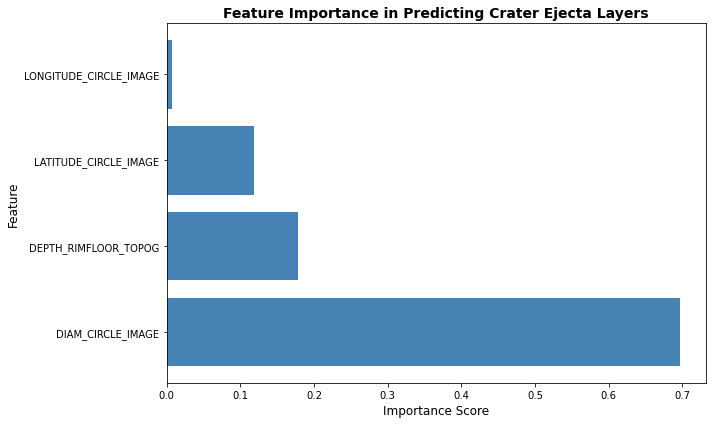

In [28]:
#Visualization of dataset
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Predicting Crater Ejecta Layers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

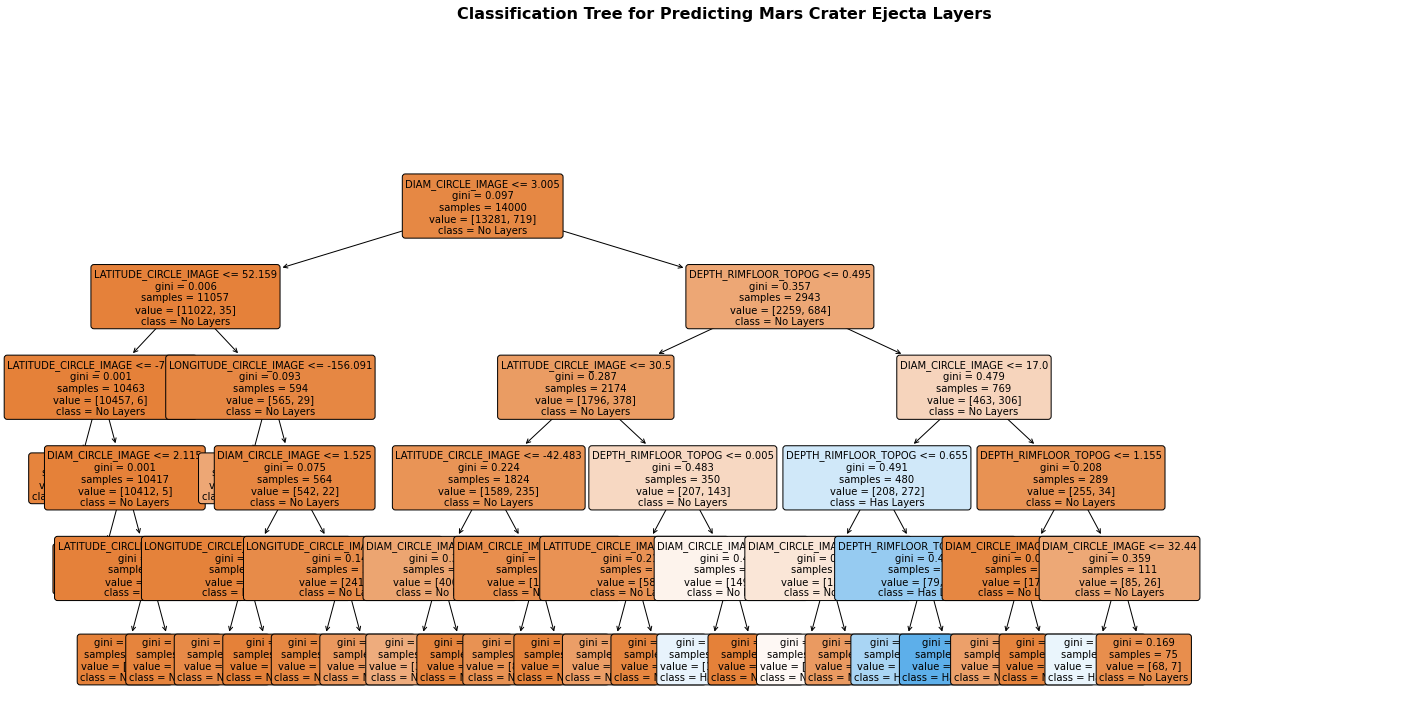

In [29]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=explanatory_vars,
          class_names=['No Layers', 'Has Layers'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Classification Tree for Predicting Mars Crater Ejecta Layers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()